In [1]:
#WEEK2 TASK1 CODE1

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [5]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [6]:
pima_df = pd.read_csv(url, header=None, names=columns)

In [8]:
print("Dataset Shape (rows, cols):", pima_df.shape)

Dataset Shape (rows, cols): (768, 9)


In [7]:
print("\nFirst 3 rows of raw dataset:")


First 3 rows of raw dataset:


In [9]:
print(pima_df.head(3))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  


In [10]:
zero_counts = (pima_df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()

In [11]:
print("\nInvalid Zero Values per column:\n", zero_counts)


Invalid Zero Values per column:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
#TASK1 CODE2

In [22]:
from sklearn.impute import SimpleImputer

In [23]:
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [24]:
pima_df[cols_to_impute] = pima_df[cols_to_impute].replace(0, np.nan)

In [25]:
print("Missing values after marking zeros:\n", pima_df.isnull().sum())

Missing values after marking zeros:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [26]:
imputer = SimpleImputer(strategy='median')

In [27]:
pima_df[cols_to_impute] = imputer.fit_transform(pima_df[cols_to_impute])

In [28]:
print("\nMissing values after statistical median imputation:\n", pima_df.isnull().sum())


Missing values after statistical median imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [29]:
#TASK1 CODE3

In [30]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [31]:
features = columns[:-1]

In [32]:
X = pima_df[features]

In [33]:
min_max_scaler = MinMaxScaler()

In [34]:
X_normalized = min_max_scaler.fit_transform(X)

In [35]:
print("Normalized Range Boundaries (Min/Max):", X_normalized.min(), "to", X_normalized.max())

Normalized Range Boundaries (Min/Max): 0.0 to 1.0000000000000002


In [36]:
standard_scaler = StandardScaler()

In [37]:
X_standardized = standard_scaler.fit_transform(X)

In [38]:
print("Standardized Mean (approx 0):", round(X_standardized.mean(), 4))

Standardized Mean (approx 0): 0.0


In [39]:
print("Standardized Std Dev (approx 1):", round(X_standardized.std(), 4))

Standardized Std Dev (approx 1): 1.0


In [ ]:
#TASK1 CODE4

In [42]:
from sklearn.preprocessing import PowerTransformer

In [43]:
original_skew = pima_df['Insulin'].skew()

In [44]:
print("Original skewness coefficient of 'Insulin':", round(original_skew, 4))

Original skewness coefficient of 'Insulin': 3.38


In [45]:
power_transformer = PowerTransformer(method='yeo-johnson')

In [46]:
insulin_transformed = power_transformer.fit_transform(pima_df[['Insulin']])

In [47]:
transformed_skew = pd.Series(insulin_transformed.flatten()).skew()

In [48]:
print("Skewness coefficient after Power Transformation:", round(transformed_skew, 4))

Skewness coefficient after Power Transformation: 0.0276


In [49]:
#task1code5

In [50]:
processed_pima_df = pd.DataFrame(data=X_standardized, columns=features)

In [51]:
processed_pima_df['Outcome'] = pima_df['Outcome']

In [52]:
processed_pima_df.to_csv("processed_pima_diabetes.csv", index=False)

In [53]:
print("Processed Pima dataset exported successfully to 'processed_pima_diabetes.csv'. Shape:", processed_pima_df.shape)

Processed Pima dataset exported successfully to 'processed_pima_diabetes.csv'. Shape: (768, 9)


In [ ]:
#TASK2 CODE1

In [54]:
import pandas as pd

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [57]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [58]:
sonar_columns = sonar_features + ['Class']

In [59]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [60]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [61]:
X_sonar = sonar_df[sonar_features]

In [62]:
scaler = StandardScaler()

In [63]:
X_sonar_scaled = scaler.fit_transform(X_sonar)

In [64]:
print("Standardized features shape:", X_sonar_scaled.shape)

Standardized features shape: (208, 60)


In [ ]:
#TASK2 CODE2

In [65]:
from sklearn.decomposition import PCA

In [66]:
pca_90 = PCA(n_components=0.90, random_state=42)

In [67]:
X_pca_90 = pca_90.fit_transform(X_sonar_scaled)

In [68]:
print("Original dimensions count:", X_sonar_scaled.shape[1])

Original dimensions count: 60


In [69]:
print("Reduced dimensions count (to preserve 90% variance):", X_pca_90.shape[1])

Reduced dimensions count (to preserve 90% variance): 22


In [ ]:
#TASK2CODE3

In [70]:
import matplotlib.pyplot as plt

In [71]:
import numpy as np

In [72]:
pca_full = PCA(random_state=42)

In [73]:
pca_full.fit(X_sonar_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [75]:
plt.figure(figsize=(7, 4))

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

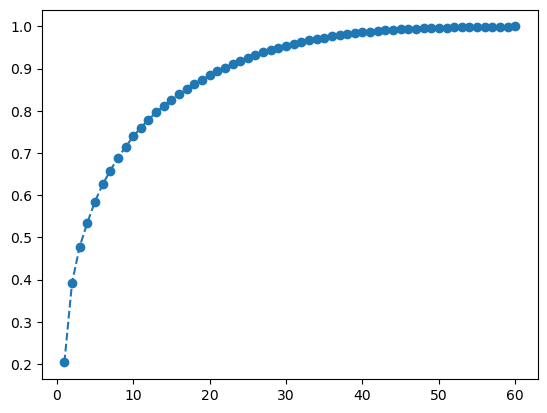

In [76]:
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

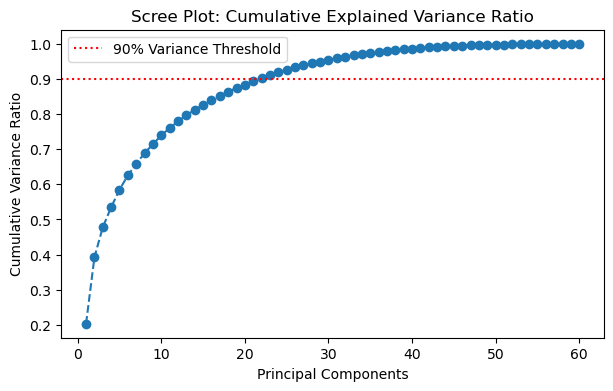

In [77]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance Threshold')
plt.title("Scree Plot: Cumulative Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()
plt.show()

In [78]:
#TASK2 CODE4

In [79]:
from sklearn.manifold import TSNE

In [80]:
import seaborn as sns

In [81]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

In [83]:
X_tsne = tsne.fit_transform(X_sonar_scaled)

In [85]:
tsne_df = pd.DataFrame(X_tsne, columns=['Dim_1', 'Dim_2'])

In [86]:
tsne_df['Class'] = sonar_df['Class']

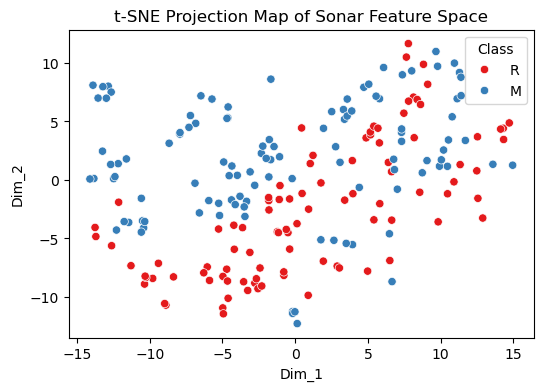

In [87]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue='Class', palette='Set1')
plt.title("t-SNE Projection Map of Sonar Feature Space")
plt.show()

In [ ]:
#TASK2 CODE5

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
from sklearn.metrics import accuracy_score

In [91]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_sonar_scaled, sonar_df['Class_numeric'], test_size=0.3, random_state=42)

In [92]:
lr_raw = LogisticRegression()

In [93]:
lr_raw.fit(X_train_raw, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [94]:
acc_raw = accuracy_score(y_test, lr_raw.predict(X_test_raw))

In [95]:
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca_90, sonar_df['Class_numeric'], test_size=0.3, random_state=42)

In [96]:
lr_pca = LogisticRegression()

In [97]:
lr_pca.fit(X_train_pca, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [98]:
acc_pca = accuracy_score(y_test, lr_pca.predict(X_test_pca))

In [99]:
print(f"Accuracy using all 60 scaled features: {acc_raw * 100:.2f}%")

Accuracy using all 60 scaled features: 76.19%


In [100]:
print(f"Accuracy using {X_pca_90.shape[1]} PCA components:  {acc_pca * 100:.2f}%")

Accuracy using 22 PCA components:  87.30%


In [ ]:
#TASK3 CODE1

In [101]:
from sklearn.feature_selection import SelectKBest, f_classif

In [102]:
selector = SelectKBest(score_func=f_classif, k=4)

In [103]:
selector.fit(X_standardized, pima_df['Outcome'])

,score_func,<function f_c...x7c48fd7d1940>
,k,4


In [104]:
anova_scores = pd.DataFrame({'Feature': features, 'F-Score': selector.scores_}).sort_values(by='F-Score', ascending=False)

In [105]:
print("ANOVA F-Test Scores:\n", anova_scores)

ANOVA F-Test Scores:
                     Feature     F-Score
1                   Glucose  245.667855
5                       BMI   82.629271
7                       Age   46.140611
0               Pregnancies   39.670227
3             SkinThickness   37.078538
4                   Insulin   33.190796
6  DiabetesPedigreeFunction   23.871300
2             BloodPressure   21.631580


In [ ]:
#TASK3 CODE2

In [106]:
from sklearn.feature_selection import RFE

In [107]:
from sklearn.linear_model import LogisticRegression

In [108]:
estimator = LogisticRegression()

In [109]:
rfe = RFE(estimator=estimator, n_features_to_select=4)

In [110]:
rfe.fit(X_standardized, pima_df['Outcome'])

,estimator,LogisticRegression()
,n_features_to_select,4
,step,1
,verbose,0
,importance_getter,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [111]:
rfe_support = pd.DataFrame({'Feature': features, 'Selected': rfe.support_, 'Ranking': rfe.ranking_}).sort_values(by='Ranking')

In [112]:
print("RFE Selected Features:\n", rfe_support)

RFE Selected Features:
                     Feature  Selected  Ranking
0               Pregnancies      True        1
1                   Glucose      True        1
6  DiabetesPedigreeFunction      True        1
5                       BMI      True        1
7                       Age     False        2
2             BloodPressure     False        3
4                   Insulin     False        4
3             SkinThickness     False        5


In [ ]:
#TASK3 CODE3

In [113]:
from sklearn.linear_model import LogisticRegression

In [114]:
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)

In [115]:
lasso.fit(X_standardized, pima_df['Outcome'])

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [116]:
lasso_coefs = pd.DataFrame({'Feature': features, 'Coefficient': lasso.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)

In [117]:
print("RFE Selected Features:\n", rfe_support)

RFE Selected Features:
                     Feature  Selected  Ranking
0               Pregnancies      True        1
1                   Glucose      True        1
6  DiabetesPedigreeFunction      True        1
5                       BMI      True        1
7                       Age     False        2
2             BloodPressure     False        3
4                   Insulin     False        4
3             SkinThickness     False        5


In [ ]:
#TASK3 CODE4

In [118]:
from sklearn.linear_model import LogisticRegression

In [119]:
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)

In [120]:
lasso.fit(X_standardized, pima_df['Outcome'])

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [121]:
lasso_coefs = pd.DataFrame({'Feature': features, 'Coefficient': lasso.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)

In [122]:
print("Lasso Regularization Coefficients:\n", lasso_coefs)

Lasso Regularization Coefficients:
                     Feature  Coefficient
1                   Glucose     1.106412
5                       BMI     0.611338
0               Pregnancies     0.399515
6  DiabetesPedigreeFunction     0.269034
7                       Age     0.134767
2             BloodPressure    -0.073190
4                   Insulin    -0.067230
3             SkinThickness     0.019400


In [123]:
#TASK3 CODE5

In [124]:
from sklearn.ensemble import RandomForestClassifier

In [125]:
import matplotlib.pyplot as plt

In [126]:
import seaborn as sns

In [127]:
import warnings

In [128]:
warnings.filterwarnings("ignore")

In [129]:
rf = RandomForestClassifier(random_state=42)

In [130]:
rf.fit(X, pima_df['Outcome'])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [131]:
importances = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)

In [132]:
print("Random Forest Feature Importances:\n", importances)

Random Forest Feature Importances:
                     Feature  Importance
1                   Glucose    0.263715
5                       BMI    0.167470
7                       Age    0.127208
6  DiabetesPedigreeFunction    0.124075
4                   Insulin    0.084843
2             BloodPressure    0.082722
0               Pregnancies    0.079268
3             SkinThickness    0.070699


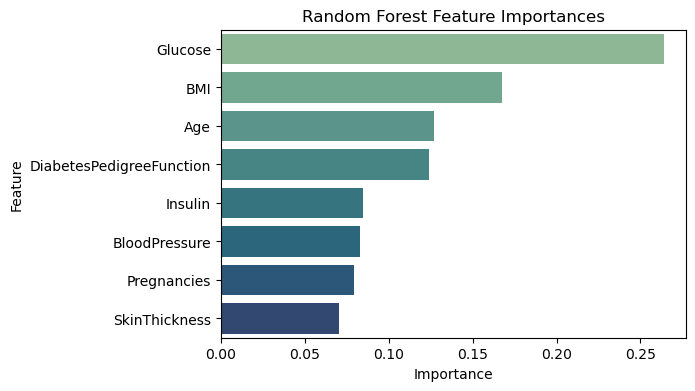

In [133]:

plt.figure(figsize=(6, 4))
sns.barplot(data=importances, x='Importance', y='Feature', palette='crest')
plt.title("Random Forest Feature Importances")
plt.show()

In [ ]:
#TASK3 CODE6

In [134]:
from sklearn.model_selection import train_test_split

In [135]:
from sklearn.metrics import classification_report

In [136]:
X_train, X_test, y_train_p, y_test_p = train_test_split(X, pima_df['Outcome'], test_size=0.3, random_state=42)


In [137]:
rf_full = RandomForestClassifier(random_state=42)

In [138]:
rf_full.fit(X_train, y_train_p)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
preds_full = rf_full.predict(X_test)

In [140]:
top_4_cols = importances.head(4)['Feature'].tolist()

In [141]:
X_train_sub = X_train[top_4_cols]

In [142]:
X_test_sub = X_test[top_4_cols]

In [143]:

rf_sub = RandomForestClassifier(random_state=42)

In [144]:
rf_sub.fit(X_train_sub, y_train_p)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [145]:
preds_sub = rf_sub.predict(X_test_sub)

In [146]:
print("--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---")
print(classification_report(y_test_p, preds_full))

--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.63      0.66      0.65        80

    accuracy                           0.75       231
   macro avg       0.72      0.73      0.73       231
weighted avg       0.75      0.75      0.75       231



In [147]:
print("\n--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---")
print(classification_report(y_test_p, preds_sub))



--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       151
           1       0.60      0.68      0.64        80

    accuracy                           0.73       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.73      0.73       231



In [ ]:
#POSTLAB 

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA


In [6]:
from sklearn.ensemble import RandomForestClassifier

In [7]:
from sklearn.feature_selection import SelectKBest, chi2

In [8]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

In [9]:
df = pd.read_csv(url)

In [10]:
print("First Five Rows\n")

First Five Rows



In [11]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [12]:
print("\nDataset Information\n")
print(df.info())



Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [13]:
print("\nStatistical Summary\n")
print(df.describe())



Statistical Summary

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [14]:
print("\nShape of Dataset:", df.shape)


Shape of Dataset: (891, 12)


In [15]:
print("\nMissing Values\n")


Missing Values



In [16]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [21]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [20]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

In [22]:
df.drop("Cabin", axis=1, inplace=True)

In [23]:
print("\nMissing Values After Preprocessing\n")
print(df.isnull().sum())



Missing Values After Preprocessing

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [24]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [25]:
encoder = LabelEncoder()


In [26]:
df["Sex"] = encoder.fit_transform(df["Sex"])

In [27]:
df["Embarked"] = encoder.fit_transform(df["Embarked"])

In [28]:
print("\nEncoded Dataset\n")


Encoded Dataset



In [29]:
print(df.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2


In [30]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 116


In [31]:
df = df.drop_duplicates()
print("Dataset Shape After Removing Duplicates:", df.shape)


Dataset Shape After Removing Duplicates: (775, 8)


In [32]:
cols = ["Age", "Fare", "SibSp", "Parch"]

In [33]:
normalizer = MinMaxScaler()

In [34]:
df[cols] = normalizer.fit_transform(df[cols])

In [35]:
scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])


In [36]:
print("\nDataset After Scaling\n")
print(df.head())



Dataset After Scaling

   Survived  Pclass  Sex       Age     SibSp     Parch      Fare  Embarked
0         0       3    1 -0.551060  0.475876 -0.500754 -0.527515         2
1         1       1    0  0.611945  0.475876 -0.500754  0.695086         0
2         1       3    0 -0.260308 -0.534545 -0.500754 -0.514627         2
3         1       1    0  0.393881  0.475876 -0.500754  0.347909         2
4         0       3    1  0.393881 -0.534545 -0.500754 -0.512240         2


In [37]:
df["Fare_Log"] = np.log1p(df["Fare"] - df["Fare"].min() + 1)

In [38]:
print("\nFare and Log Transformed Fare\n")
print(df[["Fare", "Fare_Log"]].head())



Fare and Log Transformed Fare

       Fare  Fare_Log
0 -0.527515  0.760070
1  0.695086  1.212247
2 -0.514627  0.766079
3  0.347909  1.103218
4 -0.512240  0.767187


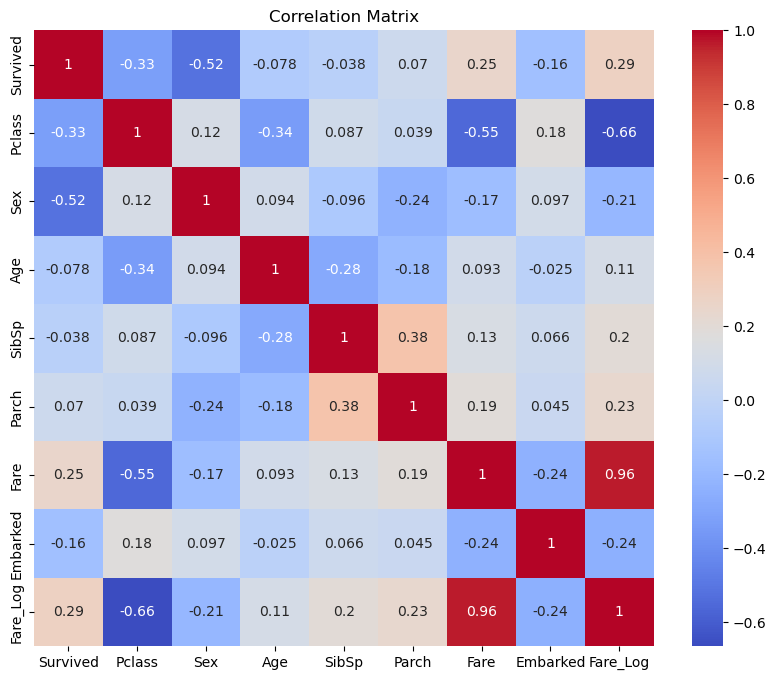

In [39]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [40]:
X = df.drop("Survived", axis=1)
y = df["Survived"]


In [41]:
X_scaled = StandardScaler().fit_transform(X)

In [42]:
pca = PCA(n_components=2)

In [43]:
X_new = pca.fit_transform(X_scaled)

In [44]:
print("\nPCA Output Shape:", X_new.shape)


PCA Output Shape: (775, 2)


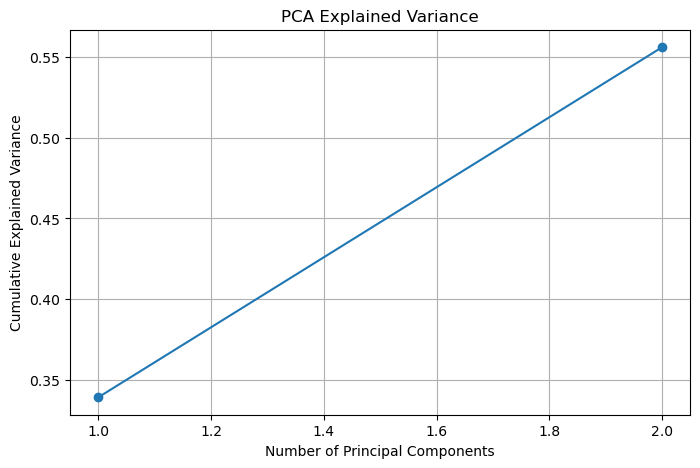

In [45]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()


In [46]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
importance = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_})

In [48]:
importance = importance.sort_values(by="Importance", ascending=False)

In [51]:
print("\nFeature Importance\n")
print(importance)


Feature Importance

    Feature  Importance
2       Age    0.250754
1       Sex    0.236303
5      Fare    0.173744
7  Fare_Log    0.163661
0    Pclass    0.074434
3     SibSp    0.040691
4     Parch    0.033599
6  Embarked    0.026813


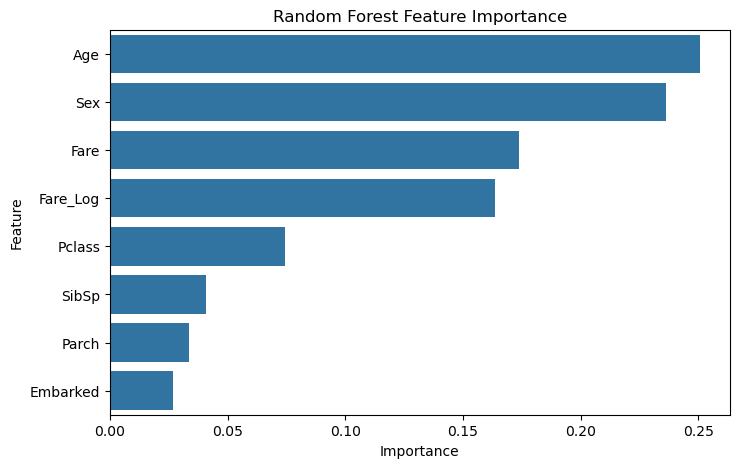

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()


In [53]:
X_chi = X - X.min()

In [54]:
selector = SelectKBest(score_func=chi2, k=5)

In [55]:
X_selected = selector.fit_transform(X_chi, y)

In [56]:
selected_features = X_chi.columns[selector.get_support()]

In [58]:
print("\nSelected Features Using Chi-Square\n")
print(selected_features)


Selected Features Using Chi-Square

Index(['Pclass', 'Sex', 'Fare', 'Embarked', 'Fare_Log'], dtype='object')


In [59]:
df.to_csv("Titanic_Preprocessed.csv", index=False)

In [61]:
print("\nPreprocessed Dataset Saved");


Preprocessed Dataset Saved
